In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import json

In [2]:
data_dir=os.path.join(os.getcwd(),"dataset_up_down","1000_200_median")

In [3]:
for dataset in os.listdir(data_dir):
    print(f"Processing dataset: {dataset}")
    dataset_path = os.path.join(data_dir, dataset)
    spikes= np.load(os.path.join(dataset_path, f'spike_data.npy'))
    gt = np.load(os.path.join(dataset_path, f'ripples.npy'))
    data=np.load(os.path.join(dataset_path, f'filtered_data.npy'))
    print(f"Spikes shape: {spikes.shape}")
    print(f"GT shape: {gt.shape}")
    print(f"Data shape: {data.shape}")
    for channel in range(spikes.shape[1]):
        print(f"Processing channel {channel}")
        num_spikes = np.sum(spikes[:, channel])
        print(f"Channel {channel} has {num_spikes} spikes")
    

Processing dataset: Amigo2_2019-07-11_11-57-07
Spikes shape: (479771, 8, 2)
GT shape: (224, 2)
Data shape: (479771, 8)
Processing channel 0
Channel 0 has 50807.0 spikes
Processing channel 1
Channel 1 has 39344.0 spikes
Processing channel 2
Channel 2 has 18636.0 spikes
Processing channel 3
Channel 3 has 15505.0 spikes
Processing channel 4
Channel 4 has 26043.0 spikes
Processing channel 5
Channel 5 has 27676.0 spikes
Processing channel 6
Channel 6 has 29242.0 spikes
Processing channel 7
Channel 7 has 32938.0 spikes
Processing dataset: Dlx1_2021-02-12_12-46-54
Spikes shape: (204267, 8, 2)
GT shape: (31, 2)
Data shape: (204267, 8)
Processing channel 0
Channel 0 has 17074.0 spikes
Processing channel 1
Channel 1 has 15469.0 spikes
Processing channel 2
Channel 2 has 15500.0 spikes
Processing channel 3
Channel 3 has 13322.0 spikes
Processing channel 4
Channel 4 has 14488.0 spikes
Processing channel 5
Channel 5 has 15369.0 spikes
Processing channel 6
Channel 6 has 15033.0 spikes
Processing chan

In [4]:
for ripple in gt:
    print(f"Start: {ripple[0]}, End: {ripple[1]}")

Start: 7829, End: 7881
Start: 9570, End: 9608
Start: 10877, End: 10925
Start: 14410, End: 14467
Start: 14575, End: 14623
Start: 14711, End: 14747
Start: 14792, End: 14830
Start: 14926, End: 15014
Start: 15067, End: 15113
Start: 16549, End: 16592
Start: 26778, End: 26853
Start: 36895, End: 36942
Start: 37554, End: 37594
Start: 37854, End: 37895
Start: 38083, End: 38125
Start: 40274, End: 40328
Start: 43810, End: 43866
Start: 51568, End: 51619
Start: 51682, End: 51728
Start: 51853, End: 51895
Start: 52002, End: 52053
Start: 52263, End: 52312
Start: 52370, End: 52414
Start: 52512, End: 52576
Start: 52740, End: 52788
Start: 52952, End: 52995
Start: 53187, End: 53228
Start: 53335, End: 53386
Start: 56443, End: 56472
Start: 56557, End: 56607
Start: 56940, End: 56990
Start: 59345, End: 59395
Start: 59516, End: 59563
Start: 59691, End: 59755
Start: 63175, End: 63226
Start: 64260, End: 64307
Start: 64470, End: 64543
Start: 64947, End: 65002
Start: 67188, End: 67246
Start: 67650, End: 67733
Star

In [5]:
ripples_start=gt[:, 0]

In [6]:
distance_ripples=ripples_start[1:] - ripples_start[:-1]
average_distance=np.mean(distance_ripples)
median_distance=np.median(distance_ripples)
min_distance=np.min(distance_ripples)
percentile=20
percentile_25=np.percentile(distance_ripples, percentile)                            
print(f"Average distance between ripple starts: {average_distance} ms")
print(f"Median distance between ripple starts: {median_distance} ms")
print(f"Minimum distance between ripple starts: {min_distance} ms")
print(f"{percentile}th Percentile distance between ripple starts: {percentile_25} ms")

Average distance between ripple starts: 1010.304347826087 ms
Median distance between ripple starts: 282.0 ms
Minimum distance between ripple starts: 62 ms
20th Percentile distance between ripple starts: 151.20000000000002 ms


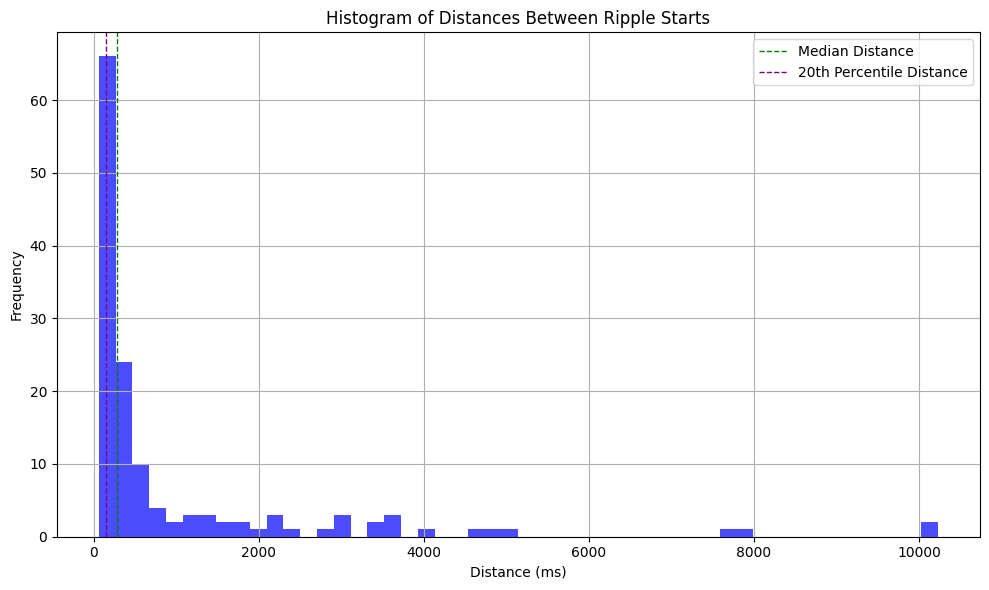

In [8]:
# Plot histogram of distances
plt.figure(figsize=(10, 6))
plt.hist(distance_ripples, range=None,bins=50, color='blue', alpha=0.7)
plt.title('Histogram of Distances Between Ripple Starts')
plt.xlabel('Distance (ms)')
plt.ylabel('Frequency')
# plt.axvline(average_distance, color='red', linestyle='dashed', linewidth=1, label='Average Distance')
plt.axvline(median_distance, color='green', linestyle='dashed', linewidth=1, label='Median Distance')
# plt.axvline(min_distance, color='orange', linestyle='dashed', linewidth=1, label='Minimum Distance')
plt.axvline(percentile_25, color='purple', linestyle='dashed', linewidth=1, label=f'{percentile}th Percentile Distance')
plt.legend()
plt.grid()
plt.tight_layout()


In [66]:
distance_ripples_end=gt[:, 0][1:] - gt[:,1][:-1]
average_distance_end=np.mean(distance_ripples_end)
median_distance_end=np.median(distance_ripples_end)
min_distance_end=np.min(distance_ripples_end)

percentile=10
percentile_25_end=np.percentile(distance_ripples_end, percentile)
print(f"Average distance between ripple ends: {average_distance_end} ms")
print(f"Median distance between ripple ends: {median_distance_end} ms")
print(f"Minimum distance between ripple ends: {min_distance_end} ms")
print(f"{percentile}th Percentile distance between ripple ends: {percentile_25_end} ms")

Average distance between ripple ends: 2220.348894348894 ms
Median distance between ripple ends: 415.0 ms
Minimum distance between ripple ends: 0 ms
10th Percentile distance between ripple ends: 80.0 ms


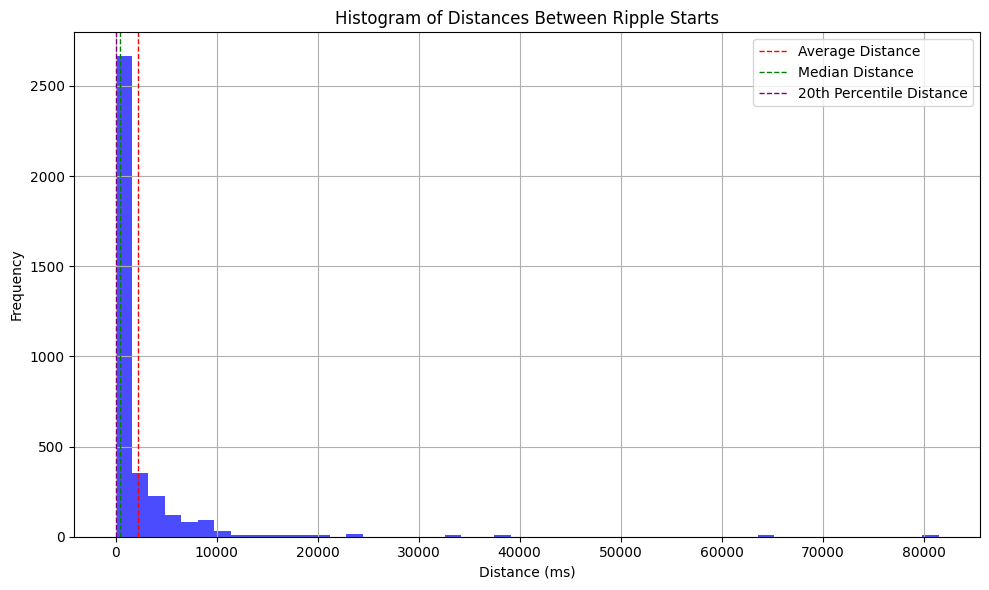

In [64]:
# Plot histogram of distances
plt.figure(figsize=(10, 6))
plt.hist(distance_ripples_end,bins=50, color='blue', alpha=0.7)
plt.title('Histogram of Distances Between Ripple Starts')
plt.xlabel('Distance (ms)')
plt.ylabel('Frequency')
plt.axvline(average_distance_end, color='red', linestyle='dashed', linewidth=1, label='Average Distance')
plt.axvline(median_distance_end, color='green', linestyle='dashed', linewidth=1, label='Median Distance')
# plt.axvline(min_distance, color='orange', linestyle='dashed', linewidth=1, label='Minimum Distance')
plt.axvline(percentile_25_end, color='purple', linestyle='dashed', linewidth=1, label=f'{percentile}th Percentile Distance')
plt.legend()
plt.grid()
plt.tight_layout()

In [53]:
# Average ripple duration
ripple_durations = gt[:, 1] - gt[:, 0]
average_duration = np.mean(ripple_durations)
median_duration = np.median(ripple_durations)
min_duration = np.min(ripple_durations)
percentile = 20
percentile_25_duration = np.percentile(ripple_durations, percentile)
max_duration = np.max(ripple_durations)

print(f"Average ripple duration: {average_duration} ms")
print(f"Median ripple duration: {median_duration} ms")
print(f"Minimum ripple duration: {min_duration} ms")
print(f"Maximum ripple duration: {max_duration} ms")
print(f"{percentile}th Percentile ripple duration: {percentile_25_duration} ms")
std_duration = np.std(ripple_durations)
print(f"Standard deviation of ripple durations: {std_duration} ms")

Average ripple duration: 50.70305676855895 ms
Median ripple duration: 49.0 ms
Minimum ripple duration: 17 ms
Maximum ripple duration: 211 ms
20th Percentile ripple duration: 39.0 ms
Standard deviation of ripple durations: 16.99368080089526 ms


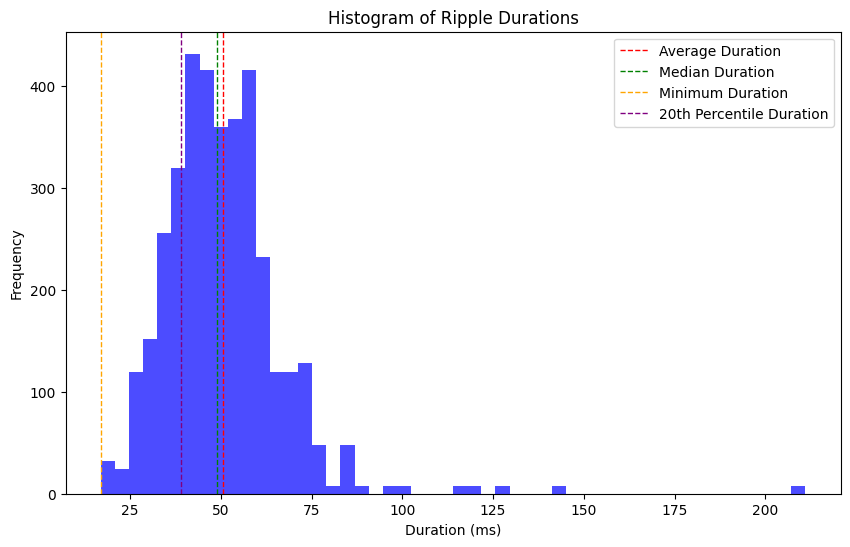

In [55]:
#Plot histogram of ripple durations
plt.figure(figsize=(10, 6))
plt.hist(ripple_durations, bins=50, color='blue', alpha=0.7)
plt.title('Histogram of Ripple Durations')
plt.xlabel('Duration (ms)')
plt.ylabel('Frequency')
plt.axvline(average_duration, color='red', linestyle='dashed', linewidth=1, label='Average Duration')
plt.axvline(median_duration, color='green', linestyle='dashed', linewidth=1, label='Median Duration')
plt.axvline(min_duration, color='orange', linestyle='dashed', linewidth=1, label='Minimum Duration')
plt.axvline(percentile_25_duration, color='purple', linestyle='dashed', linewidth=1, label=f'{percentile}th Percentile Duration')
plt.legend()
plt.show()

In [31]:
with open(os.path.join(data_dir, 'config.json'), 'r') as f:
    stats = json.load(f)

In [ ]:
num_spikes=np.sum(spikes)
num_ripples=len(gt)
spikes_per_ripple = []
ripple_length=[]

for ripple in gt:
    start, end = ripple
    spikes_in_ripple = np.sum(spikes[start:end])
    spikes_per_ripple.append(spikes_in_ripple)
    ripple_length.append(end - start)
    
ripple_length=np.array(ripple_length)
spikes_per_ripple=np.array(spikes_per_ripple)

average_spikes_per_ripple = np.mean(spikes_per_ripple)
median_spikes_per_ripple = np.median(spikes_per_ripple)
max_spikes_per_ripple = np.max(spikes_per_ripple)
min_spikes_per_ripple = np.min(spikes_per_ripple)
average_spike_rate_per_ripple = np.sum(spikes_per_ripple) /np.sum(ripple_length) if len(ripple_length) > 0 else 0
median_spike_rate_per_ripple = np.median(spikes_per_ripple/ripple_length) if len(ripple_length) > 0 else 0
max_spike_rate_per_ripple = np.max(spikes_per_ripple/ripple_length) if len(ripple_length) > 0 else 0
min_spike_rate_per_ripple = np.min(spikes_per_ripple/ripple_length) if len(ripple_length) > 0 else 0

average_spike_rate_overall= num_spikes / len(spikes) if len(spikes) > 0 else 0
average_spike_rate_non_ripple= (num_spikes - np.sum(spikes_per_ripple)) / (len(spikes) - np.sum(ripple_length))


overall_duration = len(spikes)
non_ripple_duration = overall_duration - np.sum(ripple_length)
non_ripple_spikes = num_spikes - np.sum(spikes_per_ripple)
ripple_spikes= np.sum(spikes_per_ripple)
print(f"Total number of spikes: {num_spikes}")
print(f"Total number of ripples: {num_ripples}")
print(f"Average spikes per ripple: {average_spikes_per_ripple}")
print(f"Median spikes per ripple: {median_spikes_per_ripple}")
print(f"Max spikes per ripple: {max_spikes_per_ripple}")
print(f"Min spikes per ripple: {min_spikes_per_ripple}")
print(f"Average spike rate per ripple: {average_spike_rate_per_ripple} spikes/ms")
print(f"Median spike rate per ripple: {median_spike_rate_per_ripple} spikes/ms")
print(f"Max spike rate per ripple: {max_spike_rate_per_ripple} spikes/ms")
print(f"Min spike rate per ripple: {min_spike_rate_per_ripple} spikes/ms")
print(f"Average spike rate overall: {average_spike_rate_overall} spikes/ms")
print(f"Average spike rate non-ripple: {average_spike_rate_non_ripple} spikes/ms")
print(f"Total duration: {overall_duration} ms")
print(f"Non-ripple duration: {non_ripple_duration} ms")
print(f"Non-ripple spikes: {non_ripple_spikes}")
print(f"Ripple spikes: {ripple_spikes}")


Total number of spikes: 553564
Total number of ripples: 3664
Average spikes per ripple: 18.165665938864628
Median spikes per ripple: 17.0
Max spikes per ripple: 75
Min spikes per ripple: 0
Average spike rate per ripple: 0.35827555766083885 spikes/ms
Median spike rate per ripple: 0.35294117647058826 spikes/ms
Max spike rate per ripple: 0.9333333333333333 spikes/ms
Min spike rate per ripple: 0.0 spikes/ms
Average spike rate overall: 0.06652588284722376 spikes/ms
Average spike rate non-ripple: 0.059863512592596965 spikes/ms
Total duration: 8321032 ms
Non-ripple duration: 8135256 ms
Non-ripple spikes: 487005
Ripple spikes: 66559


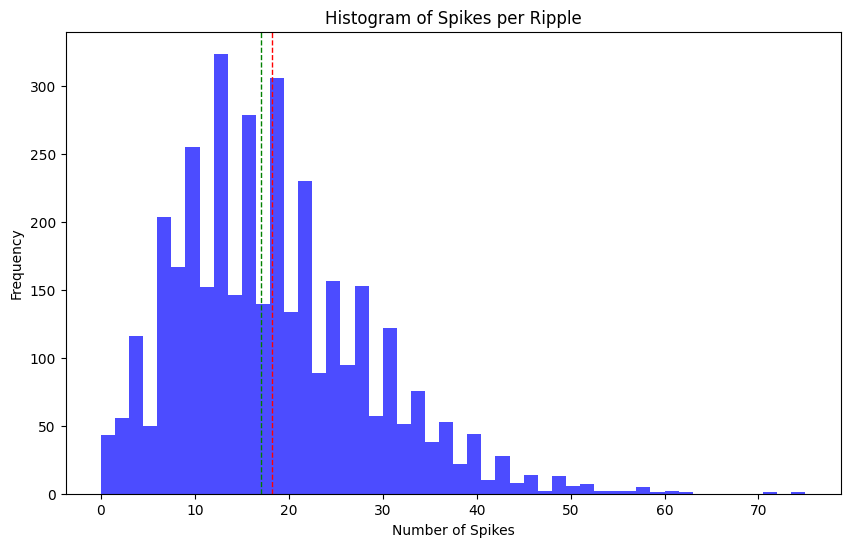

In [36]:
# Plot histogram of spikes per ripple
plt.figure(figsize=(10, 6))
plt.hist(spikes_per_ripple, bins=50, color='blue', alpha=0.7)
plt.title('Histogram of Spikes per Ripple')
plt.xlabel('Number of Spikes')
plt.ylabel('Frequency')
plt.axvline(average_spikes_per_ripple, color='red', linestyle='dashed', linewidth=1, label='Average Spikes per Ripple')
plt.axvline(median_spikes_per_ripple, color='green', linestyle='dashed', linewidth=1, label='Median Spikes per Ripple')


In [ ]:
# Take windows without ripples:
# let's say the size is the average ripple duration
gt_idx=0
padding= int(average_duration / 2)  # Half of the average ripple duration
rippleless_windows=[]
jump= int(average_duration )  # Jump size to avoid overlap
for i in range(0,len(spikes),jump):
    start,end = i, i + jump
    if end >= len(spikes):
        break
    # Skip GT ripples that end before this window
    while gt_idx < len(gt) and gt[gt_idx, 1] < start:
        gt_idx += 1

    # Check if current GT ripple overlaps this window
    if gt_idx < len(gt) and (gt[gt_idx, 0]-padding) <= end and (gt[gt_idx, 1]+padding) >= start:
        continue  # Overlaps a ripple → skip

    else:
        window = spikes[start:end]
        rippleless_windows.append(window)  # No overlap → keep it



C:\Users\NCN\AppData\Local\Temp\ipykernel_6708\2881150263.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


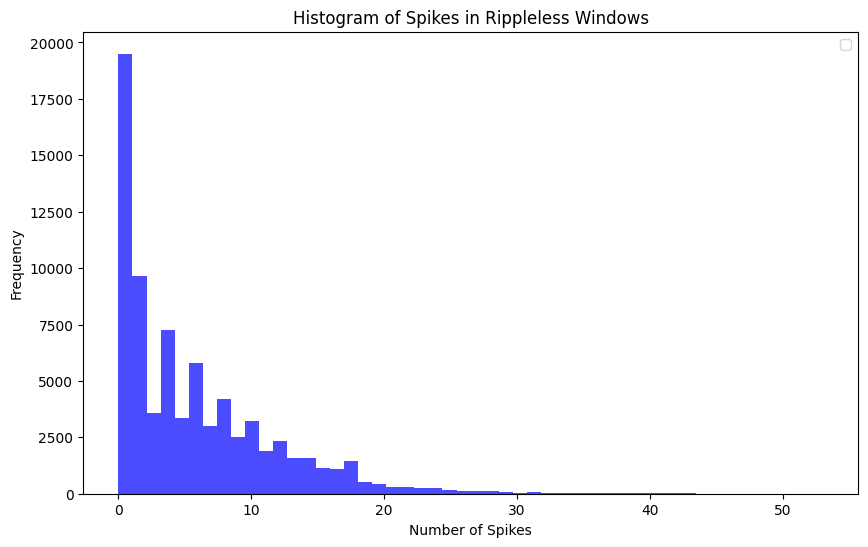

In [52]:
plt.figure(figsize=(10, 6))
spikes_per_rippleless_window = [np.sum(window) for window in rippleless_windows]
max_spikes= np.max(spikes_per_rippleless_window)
plt.hist(spikes_per_rippleless_window, bins=50,range=(0,max_spikes), color='blue', alpha=0.7)
plt.title('Histogram of Spikes in Rippleless Windows')
plt.xlabel('Number of Spikes')
plt.ylabel('Frequency')
# plt.axvline(np.mean(spikes_per_rippleless_window), color='red', linestyle='dashed', linewidth=1, label='Mean Spikes in Rippleless Windows')
# plt.axvline(np.median(spikes_per_rippleless_window), color='green', linestyle='dashed', linewidth=1, label='Median Spikes in Rippleless Windows')
plt.legend()

Text(0, 0.5, 'Frequency')

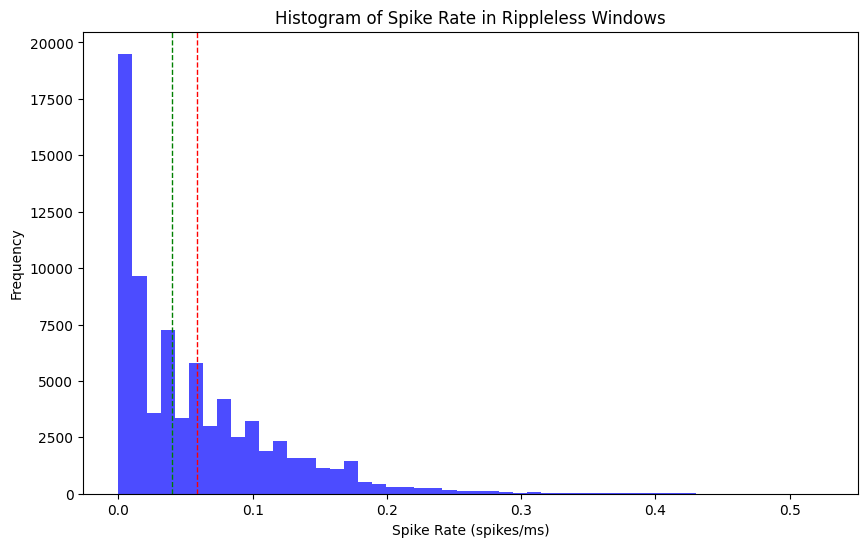

In [61]:
spikerate_per_rippleless_window = [np.sum(window) / len(window) for window in rippleless_windows]
average_spikerate_per_rippleless_window = np.mean(spikerate_per_rippleless_window)
median_spikerate_per_rippleless_window = np.percentile(spikerate_per_rippleless_window,50)

plt.figure(figsize=(10, 6))
plt.hist(spikerate_per_rippleless_window, bins=50, color='blue', alpha=0.7)
plt.axvline(average_spikerate_per_rippleless_window, color='red', linestyle='dashed', linewidth=1, label='Average Spike Rate in Rippleless Windows')
plt.axvline(median_spikerate_per_rippleless_window, color='green', linestyle='dashed', linewidth=1, label='Median Spike Rate in Rippleless Windows')
plt.title('Histogram of Spike Rate in Rippleless Windows')
plt.xlabel('Spike Rate (spikes/ms)')
plt.ylabel('Frequency')
